In [1]:
from lagp.utils.generate_data import pdf_asym_laplace, load_data, compute_dict_pars, quantile_func_asym_laplace
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import minimize
import yaml
import gpboost as gpb
import gpytorch as gpy  
import torch
from scipy.stats import multivariate_normal
#plt.style.use('ggplot')
from ipywidgets import interact, widgets, interactive
from scipy.stats import t 
from scipy.stats import nct
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable

In [36]:
def set_style():
    mpl.rcParams.update({
        # Figure / export
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "pdf.fonttype": 42,   # editable text in Illustrator
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # Typography
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 16,
        "axes.titlesize": 16,
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,

        # Axes look
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        "axes.axisbelow": True,

        # Lines
        "lines.linewidth": 1.2,
    })

LINESTYLE_BY_LABEL = {
    "Log-likelihood": "--",            # solid
    "Fisher–Laplace": "-",             # solid
    "TKC": "-",        # dashed
    "True curvature": (0, (4, 3)),     # long-dashed
}


In [37]:
def sample_y(re_n, N, noise_level, noise_dist="gaussian", df=5, rng=None):
    """Sample y = re + eps. Does NOT depend on q."""
    if rng is None:
        rng = np.random.default_rng()

    if noise_dist == "gaussian":
        eps = rng.normal(loc=0.0, scale=noise_level, size=N)
    elif noise_dist == "t":
        eps = t.rvs(df=df, loc=0.0, scale=noise_level, size=N, random_state=rng)
    else:
        raise ValueError(f"Unknown noise_dist='{noise_dist}'")

    return re_n + eps

def truth_at_q(re, q, noise_level, noise_dist="gaussian", df=5):
    """Return (mu_q, density at mu_q) under the TRUE noise distribution."""
    if noise_dist == "gaussian":
        z = norm.ppf(q)
        mu_q = re + noise_level * z
        dens = norm.pdf(z) / noise_level               # == norm.pdf(mu_q, loc=re, scale=noise_level)
    elif noise_dist == "t":
        z = t.ppf(q, df=df)
        mu_q = re + noise_level * z
        dens = t.pdf(z, df=df) / noise_level           # == t.pdf(mu_q, df=df, loc=re, scale=noise_level)
    else:
        raise ValueError(f"Unknown noise_dist='{noise_dist}'")

    return mu_q, float(dens)

In [38]:
# Initial guess for b
N = 100
var_1 = 10
re = np.random.normal(0,var_1, size = 1)
re_n = np.repeat(re, N)
miss = True
scale = 1
# create new Y
noise_levels = np.exp(np.linspace(np.log(1),np.log(10), 20)) #np.logspace(np.log10(0.05), np.log10(2), 10)
scales = []
data_densities = []
quantiles = [0.5, 0.8, 0.95] # 0.1, 0.9 
results = {q: {"densities": [], "scales": []} for q in quantiles}


noise_dist = "t"   # or "gaussian"
df = 1
rng = np.random.default_rng(123)


for noise_level in noise_levels:
     # sample y ONCE per noise level (shared across all q)
    y = sample_y(re_n=re_n, N=N, noise_level=noise_level,
                 noise_dist=noise_dist, df=df, rng=rng)


    # loop over quantiles
    for q in quantiles:
        mu_q, true_density = truth_at_q(
            re=re, q=q, noise_level=noise_level,
            noise_dist=noise_dist, df=df
        )


        # loop over quantiles 
        gpq = gpb.GPModel(group_data= np.repeat(1, repeats = N),
                                        likelihood = "asymmetric_laplace", #_constant_curvature_fisher_mode_finding", #_constant_curvature_fisher_mode_finding", 
                                        likelihood_additional_param = q,
                                        )
        params = {"estimate_aux_pars": True}
        gpq.fit(y=y, params=params) 
        # gpq.neg_log_likelihood(cov_pars=[1], y = y) 
        scale = gpq.get_aux_pars()["scale"][0]
    
        results[q]["densities"].append(true_density)
        results[q]["scales"].append(scale)

[GPBoost] [Warning] There is no intercept for modeling a possibly non-zero mean of the random effects. Consider including an intercept (= a column of 1's) in the covariates 'X' 
[GPBoost] [Warning] There is no intercept for modeling a possibly non-zero mean of the random effects. Consider including an intercept (= a column of 1's) in the covariates 'X' 
[GPBoost] [Warning] There is no intercept for modeling a possibly non-zero mean of the random effects. Consider including an intercept (= a column of 1's) in the covariates 'X' 
[GPBoost] [Warning] There is no intercept for modeling a possibly non-zero mean of the random effects. Consider including an intercept (= a column of 1's) in the covariates 'X' 
[GPBoost] [Warning] There is no intercept for modeling a possibly non-zero mean of the random effects. Consider including an intercept (= a column of 1's) in the covariates 'X' 
[GPBoost] [Warning] There is no intercept for modeling a possibly non-zero mean of the random effects. Conside

C:\Users\JumpStart\AppData\Local\Temp\ipykernel_25616\2577612611.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scale = gpq.get_aux_pars()["scale"][0]


[GPBoost] [Warning] There is no intercept for modeling a possibly non-zero mean of the random effects. Consider including an intercept (= a column of 1's) in the covariates 'X' 
[GPBoost] [Warning] There is no intercept for modeling a possibly non-zero mean of the random effects. Consider including an intercept (= a column of 1's) in the covariates 'X' 
[GPBoost] [Warning] There is no intercept for modeling a possibly non-zero mean of the random effects. Consider including an intercept (= a column of 1's) in the covariates 'X' 
[GPBoost] [Warning] There is no intercept for modeling a possibly non-zero mean of the random effects. Consider including an intercept (= a column of 1's) in the covariates 'X' 
[GPBoost] [Warning] There is no intercept for modeling a possibly non-zero mean of the random effects. Consider including an intercept (= a column of 1's) in the covariates 'X' 
[GPBoost] [Warning] There is no intercept for modeling a possibly non-zero mean of the random effects. Conside

C:\Users\JumpStart\AppData\Local\Temp\ipykernel_25616\1595382170.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 1])


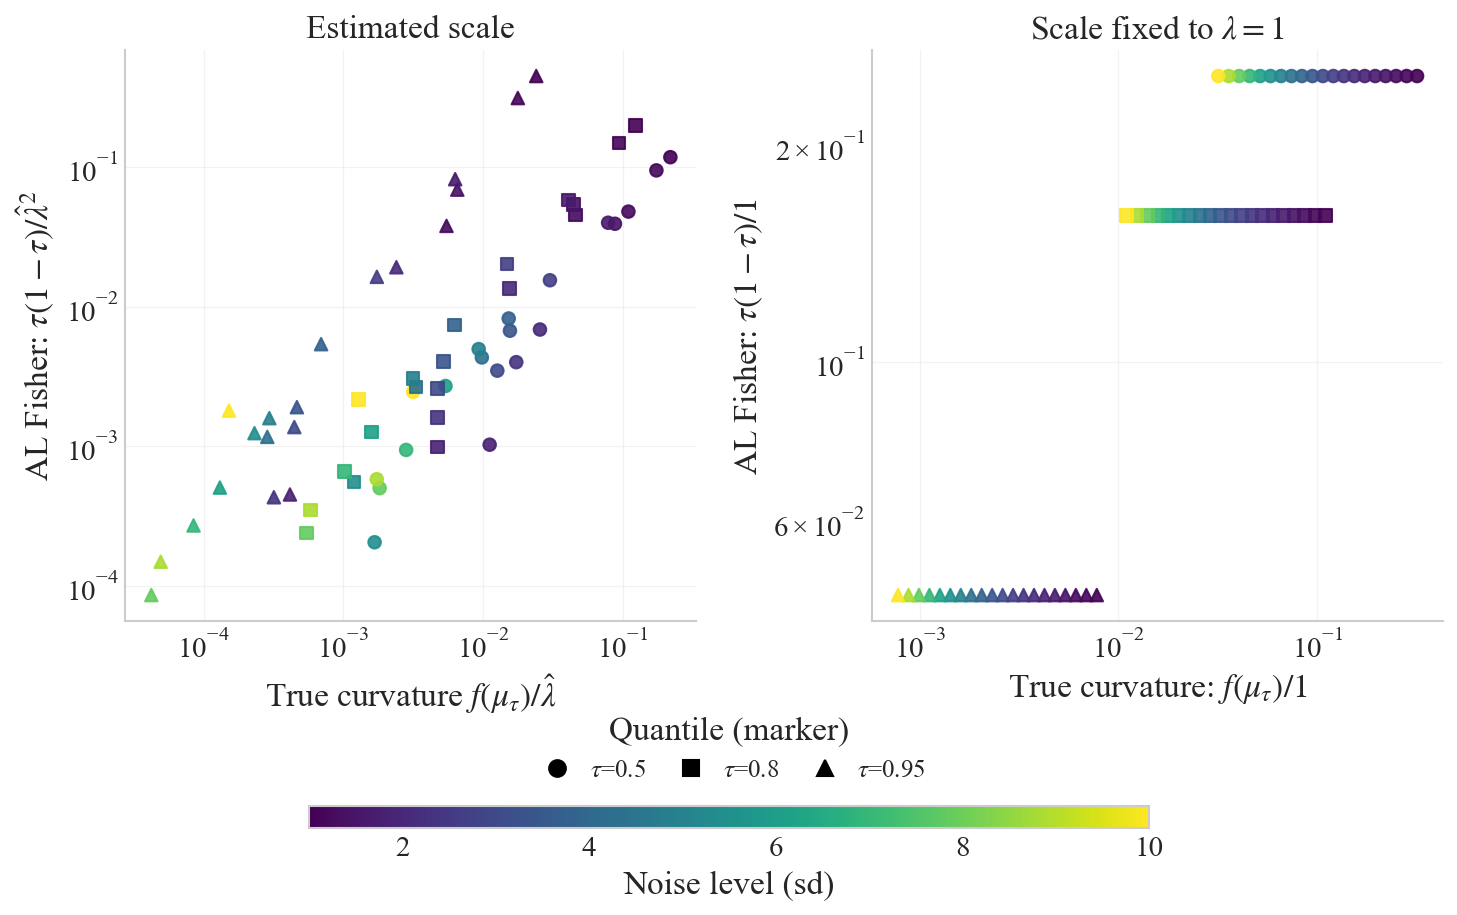

In [39]:
markers = ['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>', '*']  # enough for many quantiles
marker_map = {q: markers[i % len(markers)] for i, q in enumerate(quantiles)}

noise_arr = np.asarray(noise_levels, dtype=float).reshape(-1)
norm_ = plt.Normalize(vmin=noise_arr.min(), vmax=noise_arr.max())
cmap = plt.cm.viridis  # or any other colormap you like

plt.style.use("seaborn-v0_8-whitegrid")
# side-by-side axes
set_style()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), sharex=False, sharey=False)
ax1.set_box_aspect(1)
ax2.set_box_aspect(1)

for q in quantiles:
    densities = np.asarray(results[q]["densities"], dtype=float).reshape(-1)  # true f_Y(mu_q)
    scales    = np.asarray(results[q]["scales"],    dtype=float).reshape(-1)  # estimated AL scale

    # --- LEFT: estimated scale ---
    x_hat = (densities / scales)          # / N if you want per-observation
    y_hat = (q * (1 - q)) / (scales ** 2) # / N if you want per-observation

    ax1.scatter(
        x_hat, y_hat,
        c=noise_arr, cmap=cmap, norm=norm_,
        marker=marker_map[q],
        alpha=0.9
    )
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    # --- RIGHT: scale fixed to 1 ---
    x_fix = densities
    y_fix = np.full_like(x_fix, q * (1 - q))

    ax2.scatter(
        x_fix, y_fix,
        c=noise_arr, cmap=cmap, norm=norm_,
        marker=marker_map[q],
        alpha=0.9
    )
    ax2.set_xscale("log")
    ax2.set_yscale("log")

ax1.set_title("Estimated scale")
ax1.set_xlabel(r"True curvature $f(\mu_{\tau})/\hat\lambda$")
ax1.set_ylabel(r"AL Fisher: $\tau(1-\tau)/\hat\lambda^2$")

ax2.set_title(r"Scale fixed to $\lambda = 1$")
ax2.set_xlabel(r"True curvature: $f(\mu_{\tau})/1$")
ax2.set_ylabel(r"AL Fisher: $\tau(1-\tau)/1$")

# --- bottom legend (quantiles) ---
quantile_handles = [
    Line2D([0], [0], marker=marker_map[q], linestyle='None',
           color='black', markersize=8, label=f"{r"$\tau$"}={q}")
    for q in quantiles
]
leg = fig.legend(
    handles=quantile_handles,
    title="Quantile (marker)",
    loc="lower center",
    ncol=len(quantiles),
    bbox_to_anchor=(0.5, 0.085),#(0.5, 0.06)   # ABOVE the colorbar
    frameon=False,
    handletextpad=0.3,
    columnspacing=0.8,
    borderaxespad=0.0 
)
# --- colorbar below the legend ---
sm = ScalarMappable(norm=norm_, cmap=cmap)
sm.set_array([])

# Make space at the bottom for BOTH legend + colorbar
plt.tight_layout(rect=[0, 0.22, 1, 1])

# Put the colorbar in its own dedicated axis at the very bottom
cax = fig.add_axes([0.22, 0.045, 0.56, 0.025])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
cbar.set_label("Noise level (sd)")

#plt.tight_layout(rect=[0, 0.22, 1, 1])
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig("al_fisher_vs_curvature.pdf", bbox_inches="tight", dpi=300)
plt.show()